In [1]:
import re
import json
from enum import Enum
from PIL import Image
from pathlib import Path
from dataclasses import dataclass

import cv2
import torch
import pymupdf
import numpy as np
from scipy.spatial import cKDTree
from openpyxl import load_workbook
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    AutoImageProcessor,
    AutoModelForObjectDetection,
)


/home/aleksandr/Рабочий стол/ai-catalog-parser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Инициализация

In [21]:
CATALOG_PATH = "../data/catalogs/2026 сантехника.pdf"
# CATALOG_PATH = "../data/catalogs/HYST Smart phone quotation 5-11.pdf"
# CATALOG_PATH = "../data/catalogs/Каталог плитка - перевести 202505.pdf"

START_PAGE = 2
PAGES_CNT = 3

In [3]:
vlm = AutoModelForImageTextToText.from_pretrained(
    "numind/NuExtract3",
    dtype=torch.bfloat16,
    device_map="auto",
).eval()
vlm_processor = AutoProcessor.from_pretrained(
    "numind/NuExtract3",
    padding_side="left",
)

detector = AutoModelForObjectDetection.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors", 
    device_map="auto"
).eval()
detector_processor = AutoImageProcessor.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors",
)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 858/858 [00:00<00:00, 3710.43it/s]


# Конвертирование каталога в набор изображений

In [4]:
def get_image(page, dpi: int = 200):
    zoom = dpi / 72
    matrix = pymupdf.Matrix(zoom, zoom)

    pixmap = page.get_pixmap(
        matrix=matrix,
        alpha=False,
    )

    mode = "RGBA" if pixmap.alpha else "RGB"
    img = Image.frombytes(mode, [pixmap.width, pixmap.height], pixmap.samples)

    return img

In [22]:
catalog = pymupdf.open(CATALOG_PATH)

pages = [
    get_image(page) for page_id, page in enumerate(catalog) 
    if page_id >= START_PAGE and page_id < PAGES_CNT + START_PAGE
]

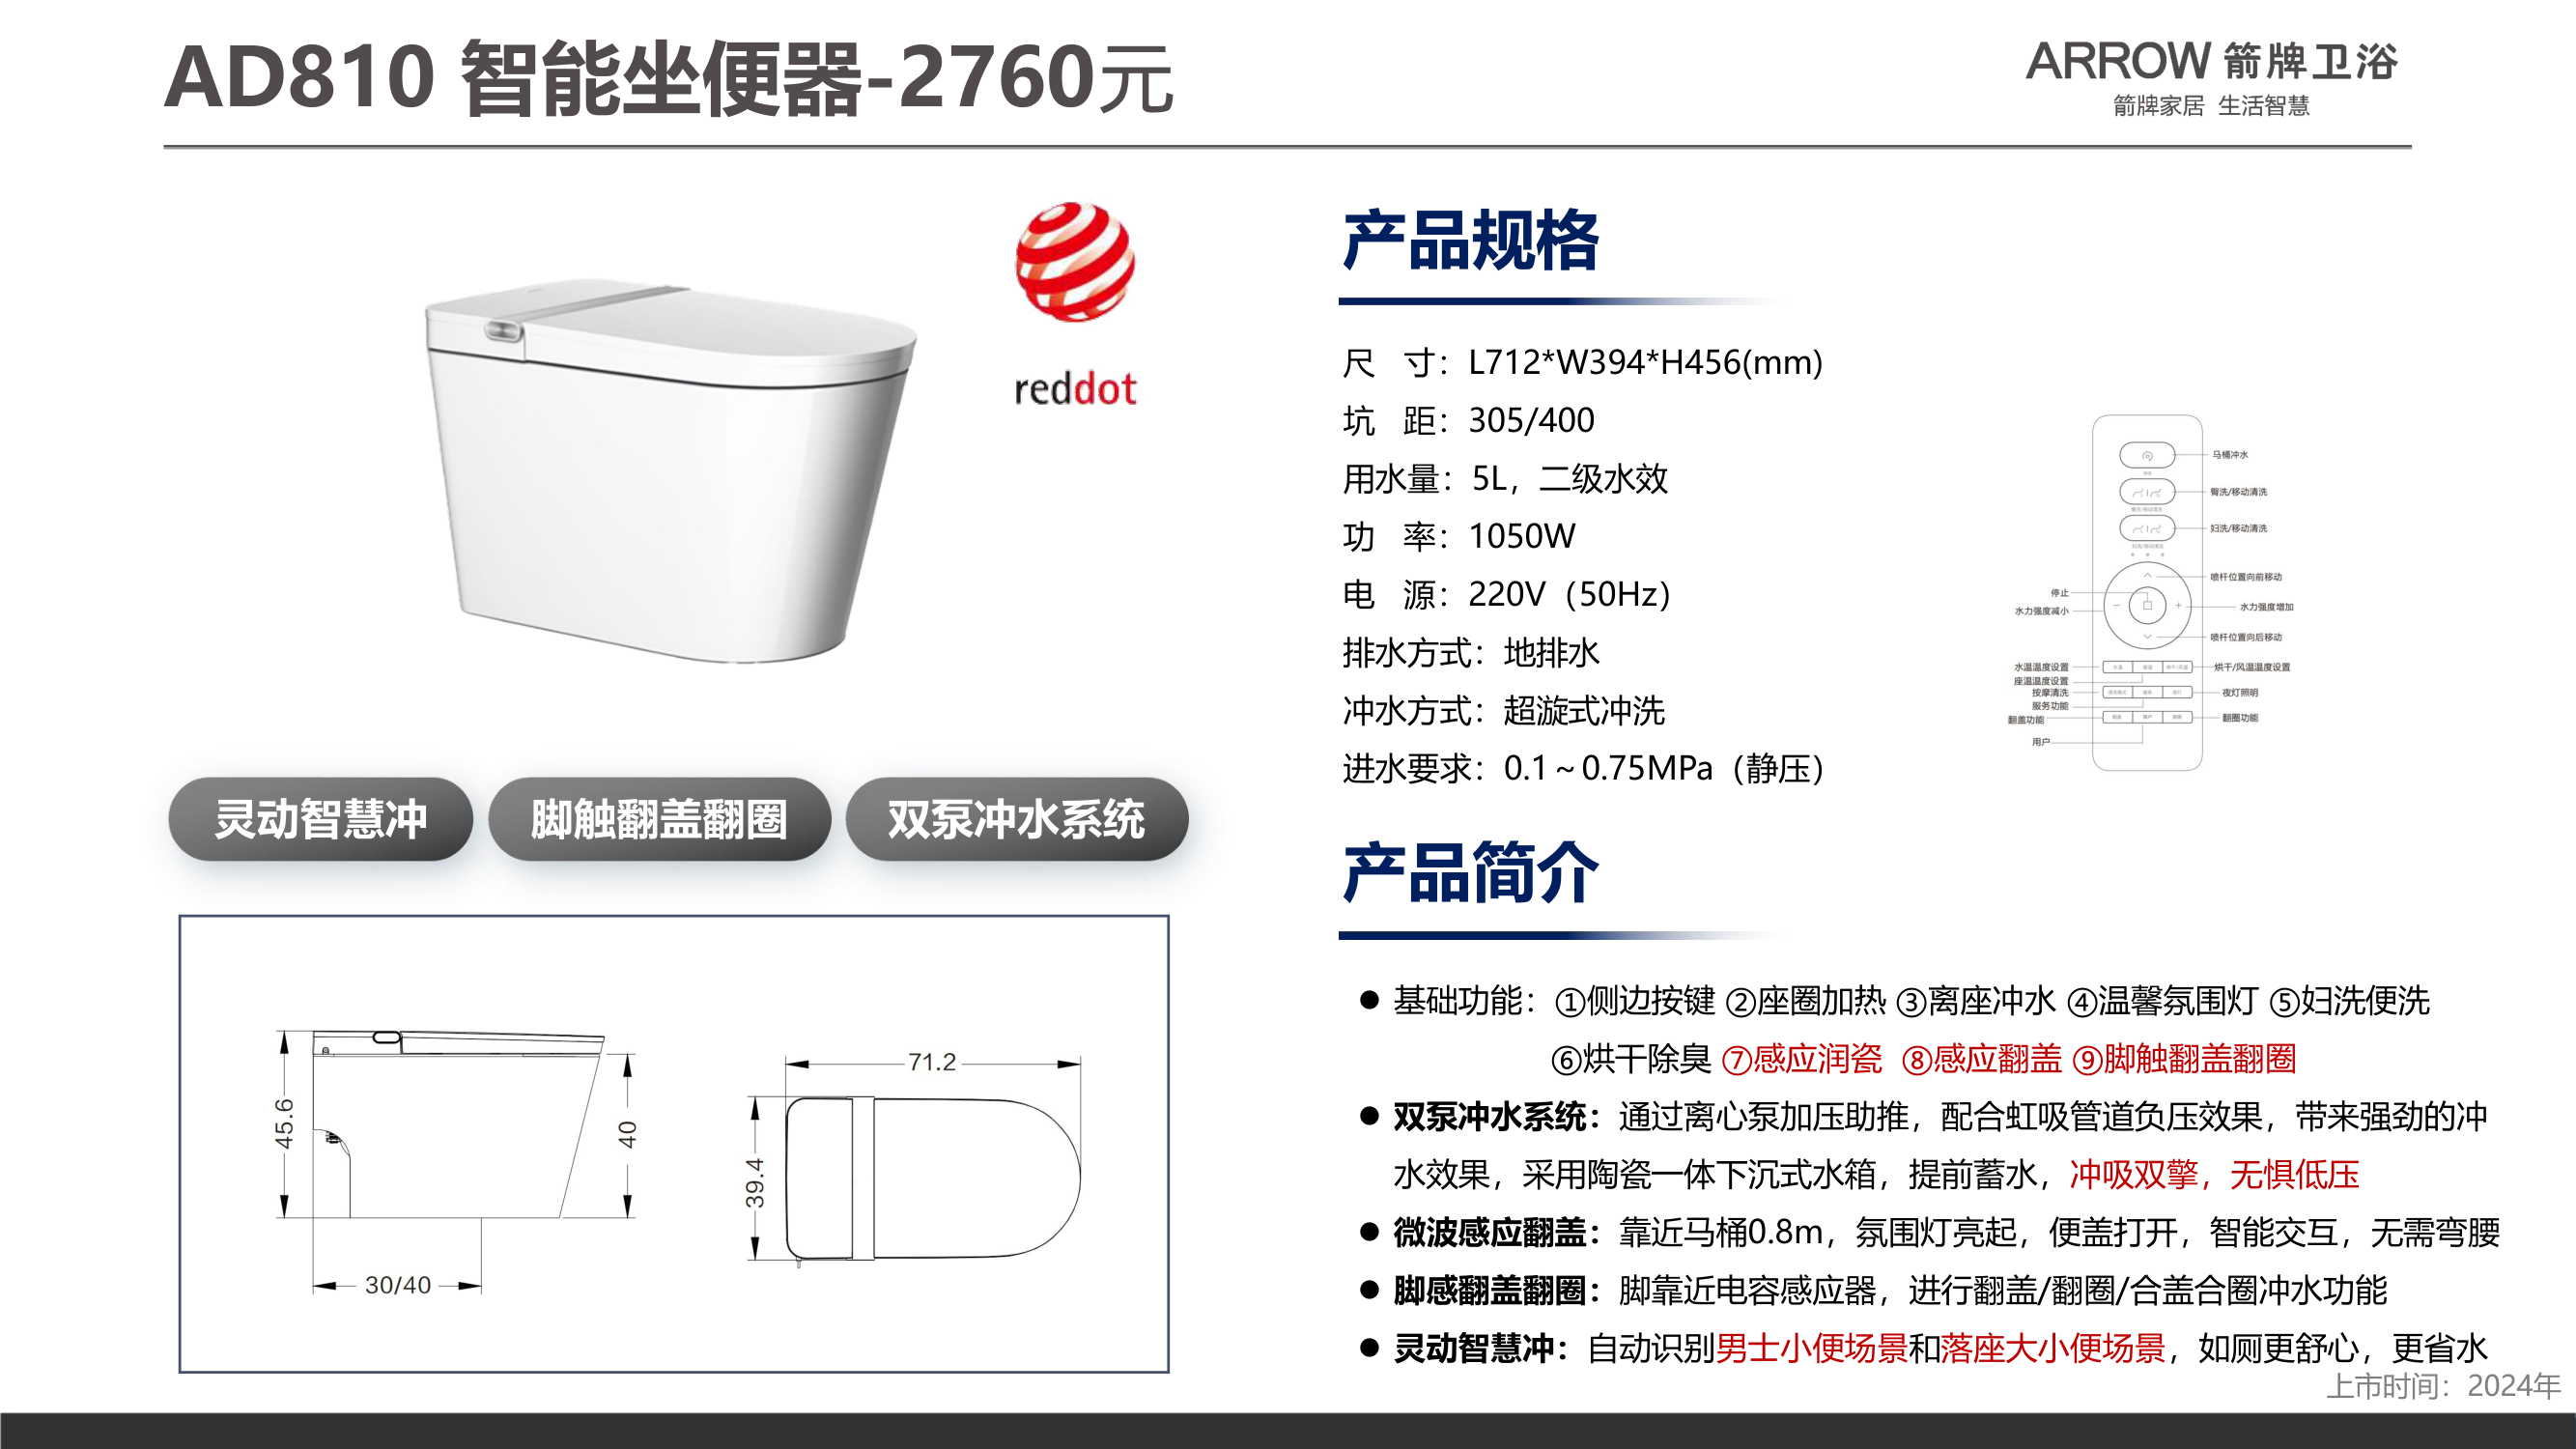

In [23]:
pages[0]

# Парсинг информации с карточек товаров

In [32]:
def run_vlm(images: list[Image], **chat_template_kwargs):
    
    enable_thinking = chat_template_kwargs.pop("enable_thinking", False)
    
    template = {
        "products": [
            {
                "name": "string",
                "description": ["verbatim-string"],
                
                "brand": "verbatim-string",
                "manufacturer": "verbatim-string",
                
                "product_center": {
                    "x": "number",
                    "y": "number",
                },
                
                "price": {
                    "value": "number",
                    "currency": "currency",
                },
                
                "specifications": {
                    "length": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "width": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "height": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "weight": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "volume": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "square": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "other": ["verbatim-string"],
                },
                
                "sku": "verbatim-string",
            }
        ]
    }

    prompt = """
    Extract ONLY real product cards from the catalog page.

    A valid product card MUST contain ALL of the following:
    - SKU / article number
    - price with numeric value (NOT null)
    - at least one technical specification with numeric value (NOT null)

    If ANY of these are missing — do NOT include the product.
    If NO valid products exist on the page — return {"products": []}.

    RULES FOR PRODUCT NAME:
    - "name" MUST contain ONLY the generic product category/type on Russian
    (e.g., "Smartphone", "Toilet", "Ceramic tile", "Power drill")
    - The name should answer the question: "What KIND of object is this?"
    - NEVER use model codes, series names, alphanumeric identifiers,
    or catalog headings as the product name
    - Patterns like "N7-6", "X200 Pro", "ABC-123", "Model XYZ" are NOT names —
    they belong in "sku"
    - If the page heading looks like "<Letters><Numbers>" or "<Word><Number>",
    treat it as a model/SKU identifier, NOT as a product name
    - Infer the product type from the image and/or specifications if no
    explicit category label is present

    RULES FOR SKU:
    - "sku" MUST capture all model codes, series identifiers, article numbers,
    and catalog IDs found on the page
    - If the page heading is alphanumeric (e.g. "N7 6", "T7200"), put it in "sku"
    - Combine multiple identifiers with " / " separator

    Each "product_center" MUST satisfy:
    - normalized coordinates in range [0.0, 1.0]
    - x and y represent the center of the main product photo ONLY
    - coordinates are relative to full page width and height
    - (0,0) is top-left, (1,1) is bottom-right

    EXAMPLES OF CORRECT EXTRACTION:
    Page heading "N7 6", image shows a phone → name: "Smartphone", sku: "N7 6"
    Page heading "TB-2000", image shows a toilet → name: "Toilet", sku: "TB-2000"
    Page heading "ProDrill X5" → name: "Power drill", sku: "ProDrill X5"
    """

    messages = [
        [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": f"{prompt}",
                    },
                ],
            }
        ]
        for image in images
    ]

    inputs = vlm_processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=enable_thinking,
        template=json.dumps(template, indent=4),
        padding=True,
        **chat_template_kwargs,
    ).to(vlm.device)

    with torch.inference_mode():
        generated_ids = vlm.generate(
            **inputs, 
            max_new_tokens=4096,
            do_sample=False,
        )
        
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

    outputs = vlm_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    if enable_thinking:
        outputs: list[str] = [
            re.sub(
                pattern=r'.*?</think>', 
                repl='', 
                string=output, 
                flags=re.DOTALL
            )
            for output in outputs
        ]

    return [
        output.strip() for output in outputs
    ]

In [33]:
vlm_results = run_vlm(pages)
vlm_results = [json.loads(res) for res in vlm_results]

print(json.dumps(vlm_results, indent=4, ensure_ascii=False))

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[
    {
        "products": [
            {
                "name": "智能坐便器",
                "description": [
                    "灵动智慧冲",
                    "脚触翻盖翻圈",
                    "双泵冲水系统"
                ],
                "brand": "ARROW 箭牌卫浴",
                "manufacturer": "箭牌家居",
                "product_center": {
                    "x": 0.3,
                    "y": 0.25
                },
                "price": {
                    "value": 2760,
                    "currency": "CNY"
                },
                "specifications": {
                    "length": {
                        "value": 712,
                        "unit": "mm"
                    },
                    "width": {
                        "value": 394,
                        "unit": "mm"
                    },
                    "height": {
                        "value": 456,
                        "unit": "mm"
                    },
                    "weight": {
             

# Перевод на русский распаршенной информации

In [34]:
def run_translator(products: list[dict], **chat_template_kwargs):
    
    enable_thinking = chat_template_kwargs.pop("enable_thinking", False)
    
    template = {
        "products": [
            {
                "name": "string",
                "description": ["string"],

                "brand": "string",
                "manufacturer": "string",

                "product_center": {
                    "x": "number",
                    "y": "number",
                },
                
                "price": {
                    "value": "number",
                    "currency": "currency",
                },

                "specifications": {
                    "length": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "width": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "height": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "weight": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "volume": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "square": {
                        "value": "number", 
                        "unit": "string"
                    },
                    "other": ["string"],
                },
                
                "sku": "string",
            }
        ]
    }

    prompt = """
    Translate the product catalog JSON to Russian.

    TRANSLATION RULES:
    - Translate ALL text to natural Russian
    - Use professional Russian technical terminology
    - Translate product names as commercial product titles used in Russian catalogs
    - Avoid literal word-by-word translation
    - Use concise catalog language

    SKU / BRAND RULES:
    - Preserve SKU exactly without translation
    - Preserve model codes exactly
    - Preserve brand names exactly
    - Do not translate brand names
    - Do not translate manufacturer names if they are company names

    STYLE RULES:
    - Use grammatically correct Russian
    - Avoid awkward literal translations
    - Prefer established Russian technical terms
    """

    messages = [
        [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": f"{prompt}",
                    },
                    {
                        "type": "text",
                        "text": json.dumps(product, ensure_ascii=False, indent=2),
                    },
                ],
            }
        ]
        for product in products
    ]

    inputs = vlm_processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=enable_thinking,
        template=json.dumps(template, indent=4),
        padding=True,
        **chat_template_kwargs,
    ).to(vlm.device)

    with torch.inference_mode():
        generated_ids = vlm.generate(
            **inputs, 
            max_new_tokens=4096,
            do_sample=False,
        )
        
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

    outputs = vlm_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    if enable_thinking:
        outputs: list[str] = [
            re.sub(
                pattern=r'.*?</think>', 
                repl='', 
                string=output, 
                flags=re.DOTALL
            )
            for output in outputs
        ]

    return [
        output.strip() for output in outputs
    ]

In [35]:
translated_results = run_translator(vlm_results, enable_thinking=True)
translated_results = [json.loads(res) for res in translated_results]

print(json.dumps(translated_results, indent=4, ensure_ascii=False))

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[
    {
        "products": [
            {
                "name": "Умная унитазная установка",
                "description": [
                    "Интеллектуальная и гибкая система смыва",
                    "Открытие крышки и кольца при касании ногой",
                    "Двухнасосная система смыва"
                ],
                "brand": "ARROW 箭牌卫浴",
                "manufacturer": "箭牌家居",
                "product_center": {
                    "x": 0.3,
                    "y": 0.25
                },
                "price": {
                    "value": 2760,
                    "currency": "CNY"
                },
                "specifications": {
                    "length": {
                        "value": 712,
                        "unit": "mm"
                    },
                    "width": {
                        "value": 394,
                        "unit": "mm"
                    },
                    "height": {
                        "value": 

# Определение изображения товара

In [35]:
class PreprocessProfile(Enum):
    """Профили под разные типы каталогов."""
    LIGHT_CATALOG   = "light"   # белый/светлый фон, типичный каталог
    DARK_CATALOG    = "dark"    # тёмный фон
    LOW_CONTRAST    = "low"     # выцветшие сканы
    DENSE_GRID      = "dense"   # много мелких карточек


def pil_to_cv2(img: Image.Image) -> np.ndarray:
    return cv2.cvtColor(np.array(img.convert("RGB")), cv2.COLOR_RGB2BGR)


def cv2_to_pil(arr: np.ndarray) -> Image.Image:
    return Image.fromarray(cv2.cvtColor(arr, cv2.COLOR_BGR2RGB))


def apply_clahe(img_bgr: np.ndarray, clip: float = 2.0, tile: int = 8) -> np.ndarray:

    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    l_eq = clahe.apply(l)

    merged = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)


def apply_unsharp_mask(
    img_bgr: np.ndarray,
    blur_ksize: int = 0,       # 0 = авто по sigma
    sigma: float = 1.5,
    strength: float = 1.5,     # коэффициент усиления краёв
    threshold: int = 5,        # порог: игнорируем слишком слабые края
) -> np.ndarray:

    blurred = cv2.GaussianBlur(img_bgr, (blur_ksize, blur_ksize), sigma)
    diff = cv2.subtract(img_bgr.astype(np.int16), blurred.astype(np.int16))

    mask = (np.abs(diff) > threshold).astype(np.float32)
    sharpened = img_bgr.astype(np.float32) + strength * diff * mask

    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_edge_overlay(
    img_bgr: np.ndarray,
    low: int = 30,
    high: int = 100,
    weight: float = 0.25,
) -> np.ndarray:

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, low, high)
    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR).astype(np.float32)

    blended = img_bgr.astype(np.float32) * (1 - weight) + edges_bgr * weight
    return np.clip(blended, 0, 255).astype(np.uint8)


def apply_gamma(img_bgr: np.ndarray, gamma: float = 1.3) -> np.ndarray:

    lut = np.array([
        min(255, int((i / 255.0) ** (1.0 / gamma) * 255))
        for i in range(256)
    ], dtype=np.uint8)
    return cv2.LUT(img_bgr, lut)


def apply_bilateral(
    img_bgr: np.ndarray,
    d: int = 9,
    sigma_color: float = 75,
    sigma_space: float = 75,
) -> np.ndarray:
    return cv2.bilateralFilter(img_bgr, d, sigma_color, sigma_space)


def apply_denoising(img_bgr: np.ndarray, h: float = 8.0) -> np.ndarray:
    return cv2.fastNlMeansDenoisingColored(img_bgr, None, h, h, 7, 21)


def apply_morphological_close(
    img_bgr: np.ndarray,
    ksize: int = 3,
) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    return cv2.morphologyEx(img_bgr, cv2.MORPH_CLOSE, kernel)


def auto_detect_profile(img: Image.Image) -> PreprocessProfile:
    """
    Анализирует гистограмму и выбирает профиль автоматически.
    Избавляет от ручного подбора для каждого каталога.
    """
    arr = np.array(img.convert("L"), dtype=np.float32)

    mean       = arr.mean()
    std        = arr.std()
    dark_ratio = (arr < 60).mean()   # доля тёмных пикселей

    if dark_ratio > 0.4:
        return PreprocessProfile.DARK_CATALOG
    if std < 35:
        return PreprocessProfile.LOW_CONTRAST
    if mean > 200 and std < 55:
        return PreprocessProfile.DENSE_GRID

    return PreprocessProfile.LIGHT_CATALOG
    
def preprocess_for_detection(
    img: Image.Image,
    profile: PreprocessProfile | None = None,
) -> Image.Image:

    if profile is None:
        profile = auto_detect_profile(img)
    
    bgr = pil_to_cv2(img)

    if profile == PreprocessProfile.LIGHT_CATALOG:
        # Типичный случай: белый каталог, товар без явных рамок
        bgr = apply_clahe(bgr, clip=2.0)
        bgr = apply_unsharp_mask(bgr, sigma=1.5, strength=1.4)
        bgr = apply_edge_overlay(bgr, low=25, high=80, weight=0.2)

    elif profile == PreprocessProfile.DARK_CATALOG:
        bgr = apply_gamma(bgr, gamma=1.4)
        bgr = apply_clahe(bgr, clip=3.0)
        bgr = apply_unsharp_mask(bgr, sigma=1.0, strength=1.2)

    elif profile == PreprocessProfile.LOW_CONTRAST:
        # Выцветший скан
        bgr = apply_bilateral(bgr)
        bgr = apply_clahe(bgr, clip=4.0, tile=4)
        bgr = apply_unsharp_mask(bgr, sigma=2.0, strength=1.8)
        bgr = apply_edge_overlay(bgr, low=15, high=60, weight=0.15)

    elif profile == PreprocessProfile.DENSE_GRID:
        # Много мелких карточек — важны тонкие разделители
        bgr = apply_bilateral(bgr, sigma_color=50, sigma_space=50)
        bgr = apply_clahe(bgr, clip=1.5)
        bgr = apply_unsharp_mask(bgr, sigma=0.8, strength=2.0)
        bgr = apply_morphological_close(bgr, ksize=2)
        bgr = apply_edge_overlay(bgr, low=20, high=70, weight=0.3)

    return cv2_to_pil(bgr)

In [36]:
def run_layout_detector(images: list[Image]):

    inputs = detector_processor(
        images=images, 
        return_tensors="pt"
    ).to(detector.device)

    with torch.inference_mode():
        outputs = detector(**inputs)

    detector_results = detector_processor.post_process_object_detection(
        outputs, 
        threshold=0.3,
        target_sizes=[img.size[::-1] for img in images]
    )

    batch_results = []
    for result in detector_results:
        boxes = result['boxes']
        label_ids = result['labels']

        images_bboxes = [
            bbox.tolist()
            for bbox, label_id in zip(boxes, label_ids)
            if detector.config.id2label[label_id.item()] == 'image'
        ]
        batch_results.append(images_bboxes)
    
    return batch_results

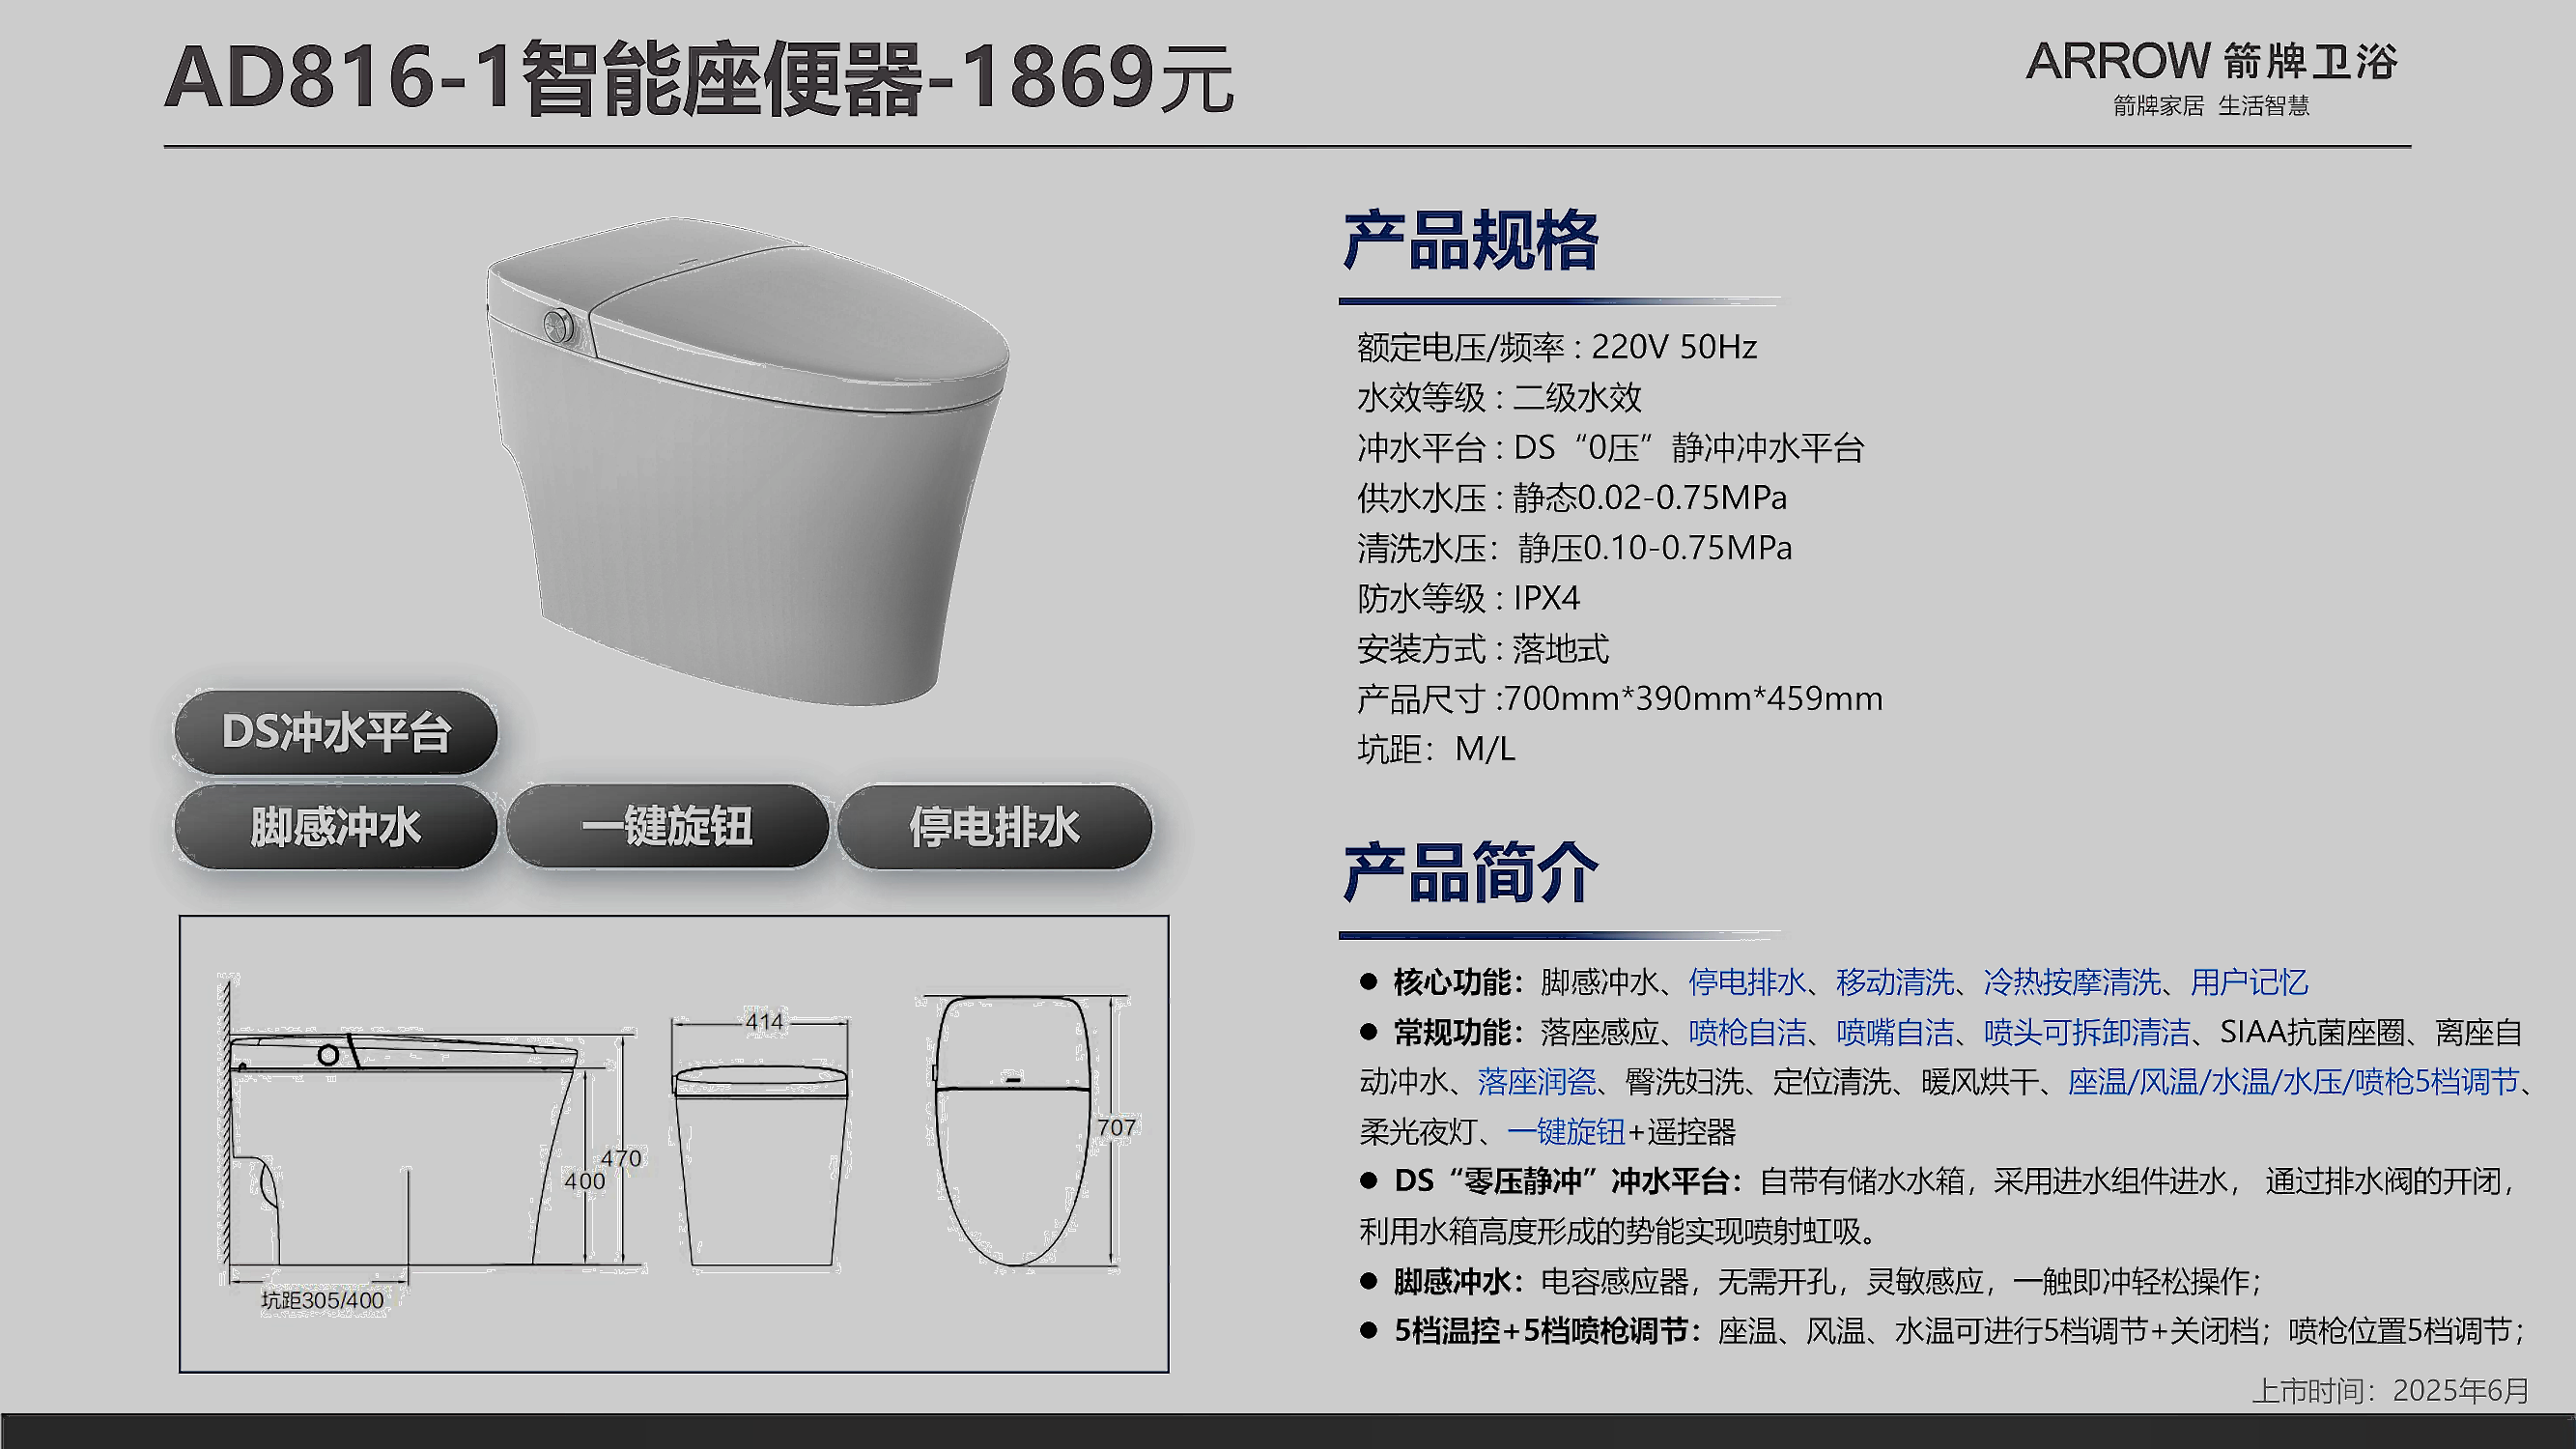

In [37]:
preprocess_for_detection(pages[2])

In [38]:
preprocessed_pages = [preprocess_for_detection(page) for page in pages]

detector_results = run_layout_detector(preprocessed_pages)
detector_results

[[[1633.5430908203125, 267.2033996582031, 2658.427978515625, 1427.7314453125]],
 [[438.5977478027344, 282.64630126953125, 947.946533203125, 688.0974731445312],
  [1046.1671142578125, 202.2574920654297, 1179.4520263671875, 338.20361328125],
  [274.74603271484375,
   1062.8060302734375,
   667.1863403320312,
   1345.4354248046875],
  [763.974853515625, 1082.56591796875, 1125.326416015625, 1311.6265869140625],
  [2074.535400390625,
   422.58050537109375,
   2377.880126953125,
   801.9796752929688]],
 [[483.0317687988281,
   215.56375122070312,
   1044.0675048828125,
   742.7688598632812],
  [171.13694763183594,
   220.6175537109375,
   1210.2794189453125,
   1372.9039306640625],
  [216.98635864257812, 1004.681640625, 673.0892333984375, 1351.031494140625],
  [694.5037841796875, 1033.6168212890625, 886.723388671875, 1321.6103515625],
  [949.4219970703125, 1024.60302734375, 1184.0966796875, 1319.724365234375]]]

In [39]:
def calculate_products_images(pages, vlm_results, detector_results, output_dir):
    

    def _normalize_name(name: str) -> str:
        return (
            name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("-", "_")
        ) 


    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results: list[tuple[dict, str]] = []

    for page, vlm_res, det_res in zip(pages, vlm_results, detector_results):

        width, height = page.size

        products = vlm_res["products"]
        if len(products) == 0:
            continue

        if len(det_res) == 0:
            full_bbox = (0, 0, width, height)

            for product in products:

                product_name = product["name"]
                product_sku = product["sku"]
                product_name = _normalize_name(product_name)

                img_path = str(output_dir / f"{product_name}_{product_sku}.png")

                cropped = page.crop(full_bbox)
                cropped.save(img_path)

                results.append((product, img_path))

            continue

        det_bboxes = np.asarray(det_res, dtype=np.float32)

        det_bbox_centers = np.column_stack([
            (det_bboxes[:, 0] + det_bboxes[:, 2]) / 2,
            (det_bboxes[:, 1] + det_bboxes[:, 3]) / 2,
        ])
        vlm_bbox_centers = np.array(
            [
                [
                    p["product_center"]["x"] * width,
                    p["product_center"]["y"] * height,
                ]
                for p in products
            ], 
            dtype=np.float32
        )

        tree = cKDTree(det_bbox_centers)
        indices = tree.query(vlm_bbox_centers, k=1)[1]

        for product, bbox_idx in zip(products, indices):

            bbox = det_bboxes[bbox_idx]

            product_name = product["name"]
            product_sku = product["sku"]
            product_name = _normalize_name(product_name)

            img_path = str(output_dir / f"{product_name}_{product_sku}.png")

            cropped = page.crop(tuple(map(int, bbox)))
            cropped.save(img_path)

            results.append((product, img_path))

    return results

In [40]:
products_with_image = calculate_products_images(
    pages,
    translated_results,
    detector_results,
    output_dir = "../data/products"
)

In [41]:
products_with_image

[({'name': 'Умная унитазная установка',
   'description': ['Интеллектуальная и гибкая система смыва',
    'Открытие крышки и кольца при касании ногой',
    'Двухнасосная система смыва'],
   'brand': 'ARROW 箭牌卫浴',
   'manufacturer': '箭牌家居',
   'product_center': {'x': 0.3, 'y': 0.25},
   'price': {'value': 2760, 'currency': 'CNY'},
   'specifications': {'length': {'value': 712, 'unit': 'mm'},
    'width': {'value': 394, 'unit': 'mm'},
    'height': {'value': 456, 'unit': 'mm'},
    'weight': {'value': None, 'unit': None},
    'volume': {'value': None, 'unit': None},
    'square': {'value': None, 'unit': None},
    'other': ['Расстояние до центра: 305/400',
     'Расход воды: 5L, класс 2',
     'Мощность: 1050W',
     'Питание: 220V (50Гц)',
     'Способ слива: слив в пол',
     'Способ смыва: сверхвихревой',
     'Требования к подаче воды: 0.1 ~ 0.75 МПа (статическое давление)']},
   'sku': 'AD810'},
  '../data/products/Умная_унитазная_установка_AD810.png'),
 ({'name': 'Умная унитазная у

# Конвертирование в номенклатуру (excel)

In [42]:
COLUMN_MAPPING = {
    "name":           "A",
    "sku":            "D",

    "weight_unit":    "F",
    "weight_flag":    "H",
    "weight_value":   "J",

    "length_unit":    "T",
    "length_flag":    "V",
    "length_value":   "X",

    "description":    "AH",

    "brand":          "AD",
    "manufacturer":   "AI",

    "image_path":     "AN",

    "volume_unit":    "AP",
    "volume_flag":    "AR",
    "volume_value":   "AT",

    "square_unit":    "AV",
    "square_flag":    "AZ",
    "square_value":   "BB",

    "origin_country": "CK",
}


def _product_to_row(product: dict, image_path: str) -> dict:
    specs = product.get("specifications") or {}

    def _val(name):
        return (specs.get(name) or {}).get("value")

    def _unit(name):
        return (specs.get(name) or {}).get("unit")
        
    def _flag(name):
        return bool(_val(name))

    name = product.get("name") or ""

    return {
        "name":           name,
        "sku":            product.get("sku"),
        "weight_unit":    _unit("weight"),
        "weight_flag":    _flag("weight"),
        "weight_value":   _val("weight"),
        "length_unit":    _unit("length"),
        "length_flag":    _flag("length"),
        "length_value":   _val("length"),
        "description":    "\n".join(product.get("description") or []),
        "brand":          product.get("brand"),
        "manufacturer":   product.get("manufacturer"),
        "image_path":     image_path,
        "volume_unit":    _unit("volume"),
        "volume_flag":    _flag("volume"),
        "volume_value":   _val("volume"),
        "square_unit":    _unit("square"),
        "square_flag":    _flag("square"),
        "square_value":   _val("square"),
        "origin_country": None,
    }


def _write_row(sheet, row: int, row_data: dict) -> None:
    for col_key, value in row_data.items():
        col = COLUMN_MAPPING.get(col_key)
        if col is not None:
            sheet[f"{col}{row}"] = value


def export_to_excel(products: list[tuple[dict, str]], template_path: str, output_path: str) -> None:
    
    workbook = load_workbook(template_path)
    sheet    = workbook.active
    row      = sheet.max_row + 1

    for product, img_path in products:
        _write_row(sheet, row, _product_to_row(product, img_path))
        row += 1

    workbook.save(output_path)

In [43]:
export_to_excel(
    products_with_image,
    template_path="../data/nomenclature/template.xlsx",
    output_path="../data/nomenclature/2026箭牌卫浴产品-5-9.xlsx",
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/nomenclature/template.xlsx'